In [2]:
# LOAD DATA AGAIN (Kernel Restarted)
import pandas as pd

sales = pd.read_csv("Sales.csv")
customers = pd.read_csv("Customers.csv")
models = pd.read_csv("MobileModels.csv")
shops = pd.read_csv("ShopLocations.csv")
offers = pd.read_csv("Offers.csv")
stocks = pd.read_csv("Stocks.csv")

print("All datasets loaded successfully!")


All datasets loaded successfully!


C:\Users\HP\AppData\Local\Temp\ipykernel_2024\246456147.py:29: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  churn_df["purchase_count"].fillna(0, inplace=True)


Customer Churn Rate (%): 1.0


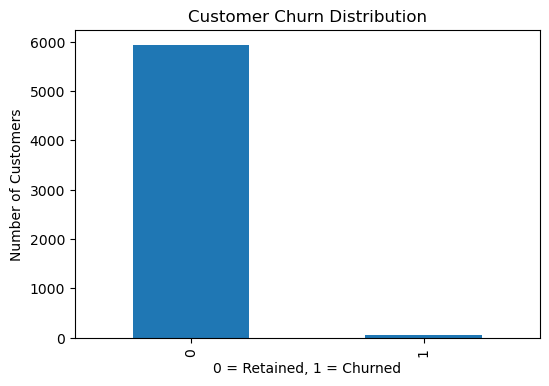

In [3]:
# CUSTOMER CHURN PREDICTION
# Churn = a customer who purchased ONLY ONCE or NEVER returned.
# These customers are considered "lost" and must be targeted 
# with offers/loyalty programs to increase repeat purchases.

import matplotlib.pyplot as plt
import pandas as pd

# OPTIONAL: Reload data if kernel was restarted
# sales = pd.read_csv("Sales.csv")
# customers = pd.read_csv("Customers.csv")

# STEP 1 — Calculate how many times each customer purchased
# We count unique sale_id per customer_id
purchase_counts = sales.groupby("customer_id")["sale_id"].nunique()

# STEP 2 — Merge purchase count into the customer table
churn_df = customers.copy()

# Add new column: purchase_count
# If customer has no purchases → fill with 0
churn_df["purchase_count"] = churn_df["customer_id"].map(purchase_counts)
churn_df["purchase_count"].fillna(0, inplace=True)

# STEP 3 — Create churn_flag column
# Rule:
# 1 → Churned Customer (0 or 1 purchase)
# 0 → Retained Customer (2 or more purchases)
churn_df["churn_flag"] = churn_df["purchase_count"].apply(
    lambda x: 1 if x <= 1 else 0
)

# STEP 4 — Calculate churn rate
churn_rate = round(churn_df["churn_flag"].mean() * 100, 2)
print("Customer Churn Rate (%):", churn_rate)

# STEP 5 — Visualize churn distribution
plt.figure(figsize=(6,4))
churn_df["churn_flag"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("0 = Retained, 1 = Churned")
plt.ylabel("Number of Customers")
plt.show()


### 11.5 Customer Churn Prediction — Explanation

**Churn Definition:**  
Churn refers to customers who stop buying from the company.  
In retail analytics, a customer is considered **churned** if:

- They purchased **only once**, OR  
- They never came back for a repeat purchase  

These customers are "lost" and must be re-engaged.

---

### Steps Performed:

#### **1. Calculated Purchase Frequency**
We counted how many times each customer bought something using:

`purchase_counts = sales.groupby("customer_id")["sale_id"].nunique()`

This gives a repeat-purchase score for every customer.

#### **2. Added purchase_count to the customer table**

Customers with no purchases were assigned `0`.

#### **3. Created Churn Flag**
We created a new column:

- **1 = Churned Customer (0 or 1 purchase)**  
- **0 = Retained Customer (2+ purchases)**  

This helps identify which customers are loyal and which are at risk.

#### **4. Calculated Churn Rate**
This tells what percentage of customers do not return.

#### **5. Visualized Churn**
A bar chart shows the distribution of churned vs retained customers.

---

### Business Insights:

- High churn means customers are **not returning** after their first purchase.  
- Churn may be high in:
  - Customers with low loyalty points
  - COD payment mode
  - Certain cities with low retention
- Helps design:
  - Loyalty programs
  - Discount campaigns
  - Targeted retention strategies

